# 06 — Trailing VRP z-scores and term-structure signals

This notebook consumes the cleaned VRP panel from notebook 05 and builds the first dynamic tenor-selection signal.

Primary signal:

`primary_vrp_signal = log(implied variance / trailing realized variance)`

The notebook creates:
- a per-tenor z-score panel,
- a pure richest-tenor model,
- an endpoint-adjusted preferred-tenor model,
- audit files for signal diagnostics.


In [1]:
# ============================================================
# Setup
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
AUDIT_DIR = DATA_DIR / "audit"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]
ENDPOINT_TENORS = [9, 33]
INTERIOR_TENORS = [12, 15, 18, 21, 24, 27, 30]

# Rolling windows use trading observations.
WINDOW_3M = 63
WINDOW_1Y = 252
MIN_PERIODS_3M = 42
MIN_PERIODS_1Y = 168

# Endpoint practical-selection rule.
ENDPOINT_ADVANTAGE_THRESHOLD = 0.25

# Input.
VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"

# Main outputs.
ZSCORE_PANEL_CSV = PROCESSED_DATA_DIR / "vrp_zscore_panel_v0_1.csv"
ZSCORE_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_zscore_panel_v0_1.parquet"

RICHEST_BY_DATE_CSV = PROCESSED_DATA_DIR / "richest_vrp_tenor_by_date_v0_1.csv"
RICHEST_BY_DATE_PARQUET = PROCESSED_DATA_DIR / "richest_vrp_tenor_by_date_v0_1.parquet"

PREFERRED_TENOR_CSV = PROCESSED_DATA_DIR / "preferred_vrp_tenor_by_date_v0_1.csv"
PREFERRED_TENOR_PARQUET = PROCESSED_DATA_DIR / "preferred_vrp_tenor_by_date_v0_1.parquet"

# Audit outputs.
LATEST_SNAPSHOT_CSV = AUDIT_DIR / "latest_vrp_zscore_snapshot_v0_1.csv"
TENOR_FREQUENCY_CSV = AUDIT_DIR / "richest_tenor_frequency_v0_1.csv"
ENDPOINT_MIDDLE_SUMMARY_CSV = AUDIT_DIR / "endpoint_middle_selection_summary_v0_1.csv"
WINNER_COMPARISON_CSV = AUDIT_DIR / "endpoint_winner_comparison_v0_1.csv"
THRESHOLD_SENSITIVITY_CSV = AUDIT_DIR / "endpoint_threshold_sensitivity_v0_1.csv"
INTERIOR_RICHEST_CSV = AUDIT_DIR / "interior_richest_vrp_tenor_by_date_v0_1.csv"

print("Project root:", PROJECT_ROOT)
print("Input VRP panel exists:", VRP_PANEL_PARQUET.exists())


Project root: C:\Users\patri\vrp_project
Input VRP panel exists: True


## 1. Load and validate source panel

The source file is the cleaned output from notebook 05. This notebook should not rebuild realized variance or RSI.


In [2]:
# ============================================================
# Load and validate VRP panel
# ============================================================

vrp_df = pd.read_parquet(VRP_PANEL_PARQUET).copy()

required_cols = [
    "trade_date",
    "target_days",
    "vix_style_vol",
    "implied_variance",
    "trailing_realized_vol",
    "trailing_realized_variance",
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
    "spx_close",
    "spx_log_return",
    "spx_rsi_14",
]

missing_cols = [c for c in required_cols if c not in vrp_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

vrp_df = vrp_df.sort_values(["trade_date", "target_days"]).reset_index(drop=True)

duplicate_rows = (
    vrp_df
    .groupby(["trade_date", "target_days"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

print("Rows:", len(vrp_df))
print("Date range:", vrp_df["trade_date"].min(), "to", vrp_df["trade_date"].max())
print("Unique dates:", vrp_df["trade_date"].nunique())
print("Duplicate date/tenor rows:", len(duplicate_rows))
print("Missing primary signal:", vrp_df["primary_vrp_signal"].isna().sum())
print("Missing SPX RSI 14:", vrp_df["spx_rsi_14"].isna().sum())

print("\nRows by tenor:")
display(vrp_df["target_days"].value_counts().sort_index())

if len(duplicate_rows) > 0:
    display(duplicate_rows)

display(vrp_df.head())


Rows: 18099
Date range: 20180625 to 20260625
Unique dates: 2011
Duplicate date/tenor rows: 0
Missing primary signal: 0
Missing SPX RSI 14: 0

Rows by tenor:


target_days
9     2011
12    2011
15    2011
18    2011
21    2011
24    2011
27    2011
30    2011
33    2011
Name: count, dtype: int64

,trade_date,target_days,rate_symbol,rate_pct,implied_variance,vix_style_vol,near_root,near_expiration,near_days,near_variance,...,vrp_trailing_vol_points,vrp_trailing_variance_ratio,vrp_trailing_log_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,vrp_forward_variance,vrp_forward_vol_points,spx_close,spx_log_return,spx_rsi_14
0,20180625,9,SOFR,1.91,0.030097,17.348587,SPXW,20180629,4.0,0.026702,...,7.106083,2.868903,1.053930,1.693784,1.053930,0.023932,9.496600,2717.07,-0.01382,41.761584
1,20180625,12,SOFR,1.91,0.030592,17.490509,SPXW,20180706,11.0,0.030591,...,8.498846,3.783771,1.330721,1.945192,1.330721,0.021557,7.985400,2717.07,-0.01382,41.761584
2,20180625,15,SOFR,1.91,0.030593,17.490890,SPXW,20180706,11.0,0.030591,...,9.144870,4.392027,1.479791,2.095716,1.479791,0.021195,7.796581,2717.07,-0.01382,41.761584
3,20180625,18,SOFR,1.91,0.030594,17.491144,SPXW,20180713,18.0,0.030594,...,9.743759,5.097135,1.628679,2.257684,1.628679,0.020172,7.282448,2717.07,-0.01382,41.761584
4,20180625,21,SOFR,1.91,0.030368,17.426522,SPXW,20180713,18.0,0.030594,...,9.409601,4.725048,1.552878,2.173718,1.552878,0.021417,7.965383,2717.07,-0.01382,41.761584


## 2. Primary-signal sanity checks

The primary signal is the log variance ratio. Positive values mean implied variance is above trailing realized variance; negative values mean implied variance is below trailing realized variance.


In [3]:
# ============================================================
# Primary signal sanity checks
# ============================================================

signal_summary = (
    vrp_df
    .groupby("target_days")[
        [
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_log_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "spx_rsi_14",
        ]
    ]
    .describe()
)

display(signal_summary)

print("Most expensive relative VRP observations:")
display(
    vrp_df
    .sort_values("primary_vrp_signal", ascending=False)
    [
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "spx_rsi_14",
        ]
    ]
    .head(25)
)

print("Cheapest relative VRP observations:")
display(
    vrp_df
    .sort_values("primary_vrp_signal", ascending=True)
    [
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "spx_rsi_14",
        ]
    ]
    .head(25)
)


vix_style_vol                                             \
                    count       mean       std        min        25%   
target_days                                                            
9                  2011.0  19.076065  9.070484   8.588728  13.480662   
12                 2011.0  19.231810  8.618185   9.325364  13.853016   
15                 2011.0  19.356858  8.296850   9.686847  14.139282   
18                 2011.0  19.483665  8.006853   9.996208  14.388831   
21                 2011.0  19.596325  7.764366  10.243030  14.626732   
24                 2011.0  19.706569  7.568364  10.413069  14.843062   
27                 2011.0  19.824019  7.411386  10.523656  15.036522   
30                 2011.0  19.933814  7.304011  10.611297  15.188156   
33                 2011.0  20.047058  7.211770  10.898647  15.313326   

                                              trailing_realized_vol  \
                   50%        75%         max                 count   
target_days                                                           
9            16.727018  21.922693  107.055162                2011.0   
12           16.940567  21.865805  101.849588                2011.0   
15           17.146458  22.064605   96.636522                2011.0   
18           17.409845  22.204891   92.998942                2011.0   
21           17.623429  22.284775   89.289969                2011.0   
24           17.802560  22.427618   86.403820                2011.0   
27           17.936999  22.517525   83.129795                2011.0   
30           18.074118  22.706873   80.414657                2011.0   
33           18.223110  22.863310   79.274362                2011.0   

                        ... primary_vrp_signal           spx_rsi_14  \
                  mean  ...                75%       max      count   
target_days             ...                                           
9            16.062037  ...           0.993112  3.581716     2011.0   
12           15.696870  ...           1.054249  2.927059     2011.0   
15           16.074684  ...           0.982090  2.854262     2011.0   
18           16.004172  ...           0.984936  2.659418     2011.0   
21           16.037640  ...           0.966564  2.446820     2011.0   
24           16.220314  ...           0.971654  2.442174     2011.0   
27           16.111909  ...           0.984611  2.195524     2011.0   
30           16.364199  ...           0.960165  2.153557     2011.0   
33           16.258730  ...           0.993569  2.153717     2011.0   

                                                                               \
                  mean        std        min        25%        50%        75%   
target_days                                                                     
9            55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
12           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
15           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
18           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
21           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
24           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
27           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
30           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   
33           55.688638  11.525885  17.658206  47.478086  57.414915  64.443556   

                        
                   max  
target_days             
9            82.900307  
12           82.900307  
15           82.900307  
18           82.900307  
21           82.900307  
24           82.900307  
27           82.900307  
30           82.900307  
33           82.900307  

[9 rows x 56 columns]

Most expensive relative VRP observations:


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,spx_rsi_14
6651,20210602,9,13.400886,2.235495,35.935152,5.994594,3.581716,58.062832
1854,20190422,9,11.664664,1.947321,35.881410,5.990109,3.580219,67.733364
5994,20210217,9,18.222651,3.286685,30.740211,5.544386,3.425572,65.582655
6660,20210603,9,14.998644,2.919119,26.399778,5.138071,3.273356,55.052304
7263,20210908,9,14.344257,3.080511,21.682557,4.656453,3.076508,60.419115
6003,20210218,9,19.349973,4.271070,20.525197,4.530474,3.021653,61.774394
7264,20210908,12,15.420184,3.568508,18.672638,4.321185,2.927059,60.419115
6032,20210223,15,21.704419,5.208984,17.361621,4.166728,2.854262,54.833172
6732,20210615,9,16.006419,3.856600,17.225787,4.150396,2.846408,61.336267
6723,20210614,9,14.830927,3.637146,16.627043,4.077627,2.811030,63.688210


Cheapest relative VRP observations:


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,spx_rsi_14
15417,20250417,9,28.195997,64.959608,0.188403,0.434054,-1.669171,41.932073
4067,20200409,33,41.451380,92.546300,0.200613,0.447899,-1.606376,54.616198
4066,20200409,30,41.581166,91.536551,0.206350,0.454258,-1.578182,54.616198
4058,20200408,33,42.798179,92.422590,0.214434,0.463071,-1.539752,53.152699
4039,20200406,30,44.676649,96.225578,0.215566,0.464291,-1.534488,49.890280
4057,20200408,30,43.390809,92.933348,0.217998,0.466902,-1.523270,53.152699
15399,20250415,9,30.001391,64.144432,0.218758,0.467716,-1.519787,45.486483
15400,20250415,12,30.494775,65.118353,0.219303,0.468298,-1.517302,45.486483
4038,20200406,27,44.875019,95.551049,0.220566,0.469644,-1.511559,49.890280
4040,20200406,33,43.560600,92.639398,0.221104,0.470217,-1.509123,49.890280


## 3. Rolling z-scores by tenor

Z-scores are calculated separately for each tenor. The rolling mean and standard deviation use a prior window, so today's signal does not use today's value in its benchmark.


In [4]:
# ============================================================
# Rolling z-score helper
# ============================================================

def add_grouped_prior_rolling_zscore(
    df,
    group_col,
    date_col,
    value_col,
    window,
    min_periods,
    output_prefix,
):
    """
    Add prior-window rolling mean/std/z-score within each group.

    The rolling mean/std are shifted by 1 observation so today's
    z-score is measured against prior history only.
    """
    df = df.sort_values([group_col, date_col]).copy()

    rolling_mean_col = f"{output_prefix}_mean"
    rolling_std_col = f"{output_prefix}_std"
    z_col = f"{output_prefix}_z"

    def prior_rolling_mean(x):
        return x.shift(1).rolling(window=window, min_periods=min_periods).mean()

    def prior_rolling_std(x):
        return x.shift(1).rolling(window=window, min_periods=min_periods).std()

    df[rolling_mean_col] = (
        df
        .groupby(group_col)[value_col]
        .transform(prior_rolling_mean)
    )

    df[rolling_std_col] = (
        df
        .groupby(group_col)[value_col]
        .transform(prior_rolling_std)
    )

    df[z_col] = (
        (df[value_col] - df[rolling_mean_col])
        / df[rolling_std_col].replace(0, np.nan)
    )

    return df


In [5]:
# ============================================================
# Build 3-month and 1-year z-scores by tenor
# ============================================================

zscore_df = vrp_df.sort_values(["target_days", "trade_date"]).copy()

zscore_df = add_grouped_prior_rolling_zscore(
    df=zscore_df,
    group_col="target_days",
    date_col="trade_date",
    value_col="primary_vrp_signal",
    window=WINDOW_3M,
    min_periods=MIN_PERIODS_3M,
    output_prefix="vrp_log_ratio_3m",
)

zscore_df = add_grouped_prior_rolling_zscore(
    df=zscore_df,
    group_col="target_days",
    date_col="trade_date",
    value_col="primary_vrp_signal",
    window=WINDOW_1Y,
    min_periods=MIN_PERIODS_1Y,
    output_prefix="vrp_log_ratio_1y",
)

zscore_df["vrp_log_ratio_blended_z"] = (
    zscore_df[["vrp_log_ratio_3m_z", "vrp_log_ratio_1y_z"]]
    .mean(axis=1)
)

zscore_df = zscore_df.sort_values(["trade_date", "target_days"]).reset_index(drop=True)

print("Rows:", len(zscore_df))

print("\nMissing 3m z-score by tenor:")
display(
    zscore_df
    .groupby("target_days")["vrp_log_ratio_3m_z"]
    .apply(lambda x: x.isna().sum())
)

print("\nMissing 1y z-score by tenor:")
display(
    zscore_df
    .groupby("target_days")["vrp_log_ratio_1y_z"]
    .apply(lambda x: x.isna().sum())
)

display(
    zscore_df[
        [
            "trade_date",
            "target_days",
            "primary_vrp_signal",
            "vrp_log_ratio_3m_z",
            "vrp_log_ratio_1y_z",
            "vrp_log_ratio_blended_z",
            "spx_rsi_14",
        ]
    ]
    .tail(45)
)


Rows: 18099

Missing 3m z-score by tenor:


target_days
9     42
12    42
15    42
18    42
21    42
24    42
27    42
30    42
33    42
Name: vrp_log_ratio_3m_z, dtype: int64


Missing 1y z-score by tenor:


target_days
9     168
12    168
15    168
18    168
21    168
24    168
27    168
30    168
33    168
Name: vrp_log_ratio_1y_z, dtype: int64

,trade_date,target_days,primary_vrp_signal,vrp_log_ratio_3m_z,vrp_log_ratio_1y_z,vrp_log_ratio_blended_z,spx_rsi_14
18054,20260618,9,-0.845055,-2.351001,-2.428957,-2.389979,55.071587
18055,20260618,12,-0.497554,-1.871379,-2.154456,-2.012917,55.071587
18056,20260618,15,-0.710881,-2.513033,-2.748666,-2.630850,55.071587
18057,20260618,18,-0.517907,-2.222150,-2.558942,-2.390546,55.071587
18058,20260618,21,-0.336358,-2.053898,-2.342387,-2.198142,55.071587
18059,20260618,24,-0.195977,-1.714822,-2.154818,-1.934820,55.071587
18060,20260618,27,-0.038538,-1.487235,-1.987454,-1.737345,55.071587
18061,20260618,30,0.035251,-1.262136,-1.908286,-1.585211,55.071587
18062,20260618,33,0.134788,-1.094885,-1.781039,-1.437962,55.071587
18063,20260622,9,0.116881,-0.572184,-0.956923,-0.764554,53.235432


## 4. Cross-tenor rankings and pure richest-tenor model

Higher z-score means a tenor is richer relative to its own history.


In [6]:
# ============================================================
# Cross-tenor ranks by date
# ============================================================

zscore_df["rank_3m_z_highest_richest"] = (
    zscore_df
    .groupby("trade_date")["vrp_log_ratio_3m_z"]
    .rank(ascending=False, method="min")
)

zscore_df["rank_1y_z_highest_richest"] = (
    zscore_df
    .groupby("trade_date")["vrp_log_ratio_1y_z"]
    .rank(ascending=False, method="min")
)

zscore_df["rank_blended_z_highest_richest"] = (
    zscore_df
    .groupby("trade_date")["vrp_log_ratio_blended_z"]
    .rank(ascending=False, method="min")
)

# Raw relative VRP rank on each date, not history-adjusted.
zscore_df["rank_raw_log_ratio_highest"] = (
    zscore_df
    .groupby("trade_date")["primary_vrp_signal"]
    .rank(ascending=False, method="min")
)

display(
    zscore_df[
        [
            "trade_date",
            "target_days",
            "primary_vrp_signal",
            "vrp_log_ratio_3m_z",
            "vrp_log_ratio_1y_z",
            "vrp_log_ratio_blended_z",
            "rank_3m_z_highest_richest",
            "rank_1y_z_highest_richest",
            "rank_blended_z_highest_richest",
            "spx_rsi_14",
        ]
    ]
    .tail(45)
)


,trade_date,target_days,primary_vrp_signal,vrp_log_ratio_3m_z,vrp_log_ratio_1y_z,vrp_log_ratio_blended_z,rank_3m_z_highest_richest,rank_1y_z_highest_richest,rank_blended_z_highest_richest,spx_rsi_14
18054,20260618,9,-0.845055,-2.351001,-2.428957,-2.389979,8.0,7.0,7.0,55.071587
18055,20260618,12,-0.497554,-1.871379,-2.154456,-2.012917,5.0,4.0,5.0,55.071587
18056,20260618,15,-0.710881,-2.513033,-2.748666,-2.630850,9.0,9.0,9.0,55.071587
18057,20260618,18,-0.517907,-2.222150,-2.558942,-2.390546,7.0,8.0,8.0,55.071587
18058,20260618,21,-0.336358,-2.053898,-2.342387,-2.198142,6.0,6.0,6.0,55.071587
18059,20260618,24,-0.195977,-1.714822,-2.154818,-1.934820,4.0,5.0,4.0,55.071587
18060,20260618,27,-0.038538,-1.487235,-1.987454,-1.737345,3.0,3.0,3.0,55.071587
18061,20260618,30,0.035251,-1.262136,-1.908286,-1.585211,2.0,2.0,2.0,55.071587
18062,20260618,33,0.134788,-1.094885,-1.781039,-1.437962,1.0,1.0,1.0,55.071587
18063,20260622,9,0.116881,-0.572184,-0.956923,-0.764554,1.0,1.0,1.0,53.235432


In [7]:
# ============================================================
# Richest tenor by date
# ============================================================

def get_top_ranked_tenor_by_date(df, rank_col, prefix):
    out = (
        df
        .dropna(subset=[rank_col])
        .sort_values(["trade_date", rank_col])
        .groupby("trade_date")
        .head(1)
        [
            [
                "trade_date",
                "target_days",
                "vix_style_vol",
                "trailing_realized_vol",
                "vrp_trailing_variance_ratio",
                "vrp_trailing_vol_ratio",
                "primary_vrp_signal",
                "vrp_log_ratio_3m_z",
                "vrp_log_ratio_1y_z",
                "vrp_log_ratio_blended_z",
                "spx_close",
                "spx_rsi_14",
            ]
        ]
        .rename(columns={
            "target_days": f"{prefix}_tenor",
            "vix_style_vol": f"{prefix}_implied_vol",
            "trailing_realized_vol": f"{prefix}_trailing_rv",
            "vrp_trailing_variance_ratio": f"{prefix}_variance_ratio",
            "vrp_trailing_vol_ratio": f"{prefix}_vol_ratio",
            "primary_vrp_signal": f"{prefix}_log_variance_ratio",
            "vrp_log_ratio_3m_z": f"{prefix}_3m_z",
            "vrp_log_ratio_1y_z": f"{prefix}_1y_z",
            "vrp_log_ratio_blended_z": f"{prefix}_blended_z",
            "spx_close": f"{prefix}_spx_close",
            "spx_rsi_14": f"{prefix}_spx_rsi_14",
        })
        .reset_index(drop=True)
    )

    return out


richest_3m_by_date = get_top_ranked_tenor_by_date(
    zscore_df,
    rank_col="rank_3m_z_highest_richest",
    prefix="richest_3m",
)

richest_1y_by_date = get_top_ranked_tenor_by_date(
    zscore_df,
    rank_col="rank_1y_z_highest_richest",
    prefix="richest_1y",
)

richest_blended_by_date = get_top_ranked_tenor_by_date(
    zscore_df,
    rank_col="rank_blended_z_highest_richest",
    prefix="richest_blended",
)

richest_by_date_df = (
    richest_3m_by_date
    .merge(richest_1y_by_date, on="trade_date", how="outer")
    .merge(richest_blended_by_date, on="trade_date", how="outer")
    .sort_values("trade_date")
    .reset_index(drop=True)
)

print("Dates in richest summary:", len(richest_by_date_df))
display(richest_by_date_df.tail(30))


Dates in richest summary: 1969


,trade_date,richest_3m_tenor,richest_3m_implied_vol,richest_3m_trailing_rv,richest_3m_variance_ratio,richest_3m_vol_ratio,richest_3m_log_variance_ratio,richest_3m_3m_z,richest_3m_1y_z,richest_3m_blended_z,...,richest_blended_implied_vol,richest_blended_trailing_rv,richest_blended_variance_ratio,richest_blended_vol_ratio,richest_blended_log_variance_ratio,richest_blended_3m_z,richest_blended_1y_z,richest_blended_blended_z,richest_blended_spx_close,richest_blended_spx_rsi_14
1939,20260513,21,16.815346,10.506017,2.561742,1.600544,0.940688,0.316684,0.194387,0.255536,...,16.815346,10.506017,2.561742,1.600544,0.940688,0.316684,0.194387,0.255536,7444.25,75.514938
1940,20260514,27,17.010834,10.704921,2.525133,1.589067,0.926294,0.291542,0.152259,0.221900,...,17.010834,10.704921,2.525133,1.589067,0.926294,0.291542,0.152259,0.221900,7501.24,77.713863
1941,20260515,30,18.240269,11.841455,2.372752,1.540374,0.864050,0.240205,0.065425,0.152815,...,18.240269,11.841455,2.372752,1.540374,0.864050,0.240205,0.065425,0.152815,7408.50,67.146096
1942,20260518,9,16.547942,10.141064,2.662692,1.631776,0.979338,0.451265,0.321004,0.386134,...,16.547942,10.141064,2.662692,1.631776,0.979338,0.451265,0.321004,0.386134,7403.05,66.573171
1943,20260519,27,17.906618,10.989793,2.654900,1.629386,0.976407,0.378735,0.229567,0.304151,...,17.906618,10.989793,2.654900,1.629386,0.976407,0.378735,0.229567,0.304151,7353.61,61.450795
1944,20260520,33,17.582967,11.342303,2.403155,1.550211,0.876783,0.219905,0.023343,0.121624,...,17.582967,11.342303,2.403155,1.550211,0.876783,0.219905,0.023343,0.121624,7432.97,65.976250
1945,20260521,33,16.920704,11.356615,2.219929,1.489942,0.797475,0.067792,-0.157831,-0.045019,...,16.920704,11.356615,2.219929,1.489942,0.797475,0.067792,-0.157831,-0.045019,7445.72,66.653563
1946,20260522,30,16.800819,11.169502,2.262524,1.504169,0.816481,0.149307,-0.085238,0.032034,...,16.800819,11.169502,2.262524,1.504169,0.816481,0.149307,-0.085238,0.032034,7473.47,68.140144
1947,20260526,9,14.691322,9.327453,2.480822,1.575063,0.908590,0.442649,0.196049,0.319349,...,14.691322,9.327453,2.480822,1.575063,0.908590,0.442649,0.196049,0.319349,7519.12,70.472169
1948,20260527,12,14.079157,8.078323,3.037462,1.742832,1.111022,0.661347,0.441180,0.551263,...,14.079157,8.078323,3.037462,1.742832,1.111022,0.661347,0.441180,0.551263,7520.36,70.535259


## 5. Signal diagnostics

These checks help identify whether the ranking is over-selecting a tenor or an endpoint.


In [8]:
# ============================================================
# Tenor-frequency diagnostics
# ============================================================

num_richest_dates = len(richest_by_date_df)

tenor_frequency_df = pd.DataFrame({
    "tenor": TARGET_TENOR_DAYS,
}).merge(
    richest_by_date_df["richest_3m_tenor"].value_counts().rename("richest_3m_count"),
    left_on="tenor",
    right_index=True,
    how="left",
).merge(
    richest_by_date_df["richest_1y_tenor"].value_counts().rename("richest_1y_count"),
    left_on="tenor",
    right_index=True,
    how="left",
).merge(
    richest_by_date_df["richest_blended_tenor"].value_counts().rename("richest_blended_count"),
    left_on="tenor",
    right_index=True,
    how="left",
)

tenor_frequency_df = tenor_frequency_df.fillna(0)

for col in [
    "richest_3m_count",
    "richest_1y_count",
    "richest_blended_count",
]:
    pct_col = col.replace("_count", "_pct")
    tenor_frequency_df[pct_col] = tenor_frequency_df[col] / num_richest_dates

display(tenor_frequency_df)


,tenor,richest_3m_count,richest_1y_count,richest_blended_count,richest_3m_pct,richest_1y_pct,richest_blended_pct
0,9,334,292,323,0.169629,0.148299,0.164043
1,12,268,264,281,0.136110,0.134078,0.142712
2,15,177,165,184,0.089893,0.083799,0.093448
3,18,146,138,140,0.074149,0.070086,0.071102
4,21,139,131,134,0.070594,0.066531,0.068055
5,24,105,111,117,0.053327,0.056374,0.059421
6,27,137,124,143,0.069578,0.062976,0.072626
7,30,192,182,198,0.097511,0.092433,0.100559
8,33,471,436,449,0.239208,0.221432,0.228035


In [9]:
# ============================================================
# Z-score distribution by tenor
# ============================================================

zscore_by_tenor_summary = (
    zscore_df
    .groupby("target_days")[
        [
            "vrp_log_ratio_3m_z",
            "vrp_log_ratio_1y_z",
            "vrp_log_ratio_blended_z",
        ]
    ]
    .agg(["mean", "median", "std", "min", "max"])
)

display(zscore_by_tenor_summary)


vrp_log_ratio_3m_z                                          \
                          mean    median       std       min       max   
target_days                                                              
9                     0.005857 -0.030931  1.122018 -4.217351  6.350125   
12                    0.008311  0.009611  1.125937 -3.769290  6.712355   
15                    0.008243  0.014166  1.152694 -4.804161  3.729206   
18                    0.003506  0.053619  1.167806 -5.743158  3.983155   
21                    0.001225  0.021339  1.183997 -5.041304  3.715088   
24                    0.000745  0.057170  1.193398 -3.795403  4.609755   
27                    0.008070  0.053433  1.209072 -3.624838  3.496539   
30                    0.014442  0.024991  1.227653 -3.532702  3.311114   
33                    0.017870  0.032528  1.240666 -3.472044  3.771062   

            vrp_log_ratio_1y_z                                          \
                          mean    median       std       min       max   
target_days                                                              
9                     0.030685 -0.019411  1.036920 -2.962171  4.268343   
12                    0.036697  0.016002  1.037630 -3.088844  4.384145   
15                    0.042746 -0.016611  1.041202 -3.063725  4.156362   
18                    0.046819  0.019662  1.046229 -3.378093  3.425248   
21                    0.052343  0.010811  1.056254 -3.194836  3.730192   
24                    0.053772  0.048357  1.061837 -3.483673  4.193295   
27                    0.054229  0.058788  1.065453 -3.367992  2.861500   
30                    0.054821  0.033237  1.072249 -3.288326  2.736646   
33                    0.056702  0.067957  1.077074 -3.230071  2.973050   

            vrp_log_ratio_blended_z                                          
                               mean    median       std       min       max  
target_days                                                                  
9                          0.017108 -0.011112  1.072128 -3.424783  5.244517  
12                         0.020220  0.007546  1.072854 -3.367903  5.548250  
15                         0.020883  0.004193  1.084958 -3.721811  3.942784  
18                         0.019190  0.030761  1.091983 -3.909951  3.704202  
21                         0.019572  0.002668  1.103423 -3.504050  3.722640  
24                         0.018655  0.038510  1.108161 -3.281996  4.401525  
27                         0.023090  0.040039  1.114426 -3.213981  2.991687  
30                         0.027408  0.032853  1.123453 -3.240051  3.012386  
33                         0.029909  0.034079  1.129880 -3.097872  3.318604

In [10]:
# ============================================================
# Endpoint versus middle-tenor selection
# ============================================================

endpoint_middle_summary = pd.DataFrame({
    "group": ["endpoint", "middle"],
    "num_tenors": [len(ENDPOINT_TENORS), len(INTERIOR_TENORS)],
    "richest_blended_count": [
        richest_by_date_df["richest_blended_tenor"].isin(ENDPOINT_TENORS).sum(),
        richest_by_date_df["richest_blended_tenor"].isin(INTERIOR_TENORS).sum(),
    ],
})

endpoint_middle_summary["richest_blended_pct"] = (
    endpoint_middle_summary["richest_blended_count"] / len(richest_by_date_df)
)

endpoint_middle_summary["selection_rate_per_tenor"] = (
    endpoint_middle_summary["richest_blended_pct"]
    / endpoint_middle_summary["num_tenors"]
)

display(endpoint_middle_summary)


,group,num_tenors,richest_blended_count,richest_blended_pct,selection_rate_per_tenor
0,endpoint,2,772,0.392077,0.196039
1,middle,7,1197,0.607923,0.086846


## 6. Endpoint-adjusted practical tenor

The pure model can select 9d or 33d frequently. The preferred-tenor rule keeps endpoints available but requires them to beat the best interior tenor by a minimum blended-z advantage.


In [11]:
# ============================================================
# Best interior tenor by date
# ============================================================

interior_zscore_df = zscore_df[
    zscore_df["target_days"].isin(INTERIOR_TENORS)
].copy()

interior_zscore_df["rank_blended_z_interior_highest_richest"] = (
    interior_zscore_df
    .groupby("trade_date")["vrp_log_ratio_blended_z"]
    .rank(ascending=False, method="min")
)

interior_richest_by_date_df = (
    interior_zscore_df
    .dropna(subset=["vrp_log_ratio_blended_z"])
    .sort_values(["trade_date", "rank_blended_z_interior_highest_richest"])
    .groupby("trade_date")
    .head(1)
    [
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "vrp_log_ratio_3m_z",
            "vrp_log_ratio_1y_z",
            "vrp_log_ratio_blended_z",
            "spx_close",
            "spx_rsi_14",
        ]
    ]
    .rename(columns={
        "target_days": "richest_interior_tenor",
        "vix_style_vol": "richest_interior_implied_vol",
        "trailing_realized_vol": "richest_interior_trailing_rv",
        "vrp_trailing_variance_ratio": "richest_interior_variance_ratio",
        "vrp_trailing_vol_ratio": "richest_interior_vol_ratio",
        "primary_vrp_signal": "richest_interior_log_variance_ratio",
        "vrp_log_ratio_3m_z": "richest_interior_3m_z",
        "vrp_log_ratio_1y_z": "richest_interior_1y_z",
        "vrp_log_ratio_blended_z": "richest_interior_blended_z",
        "spx_close": "richest_interior_spx_close",
        "spx_rsi_14": "richest_interior_spx_rsi_14",
    })
    .reset_index(drop=True)
)

display(interior_richest_by_date_df.tail(30))


,trade_date,richest_interior_tenor,richest_interior_implied_vol,richest_interior_trailing_rv,richest_interior_variance_ratio,richest_interior_vol_ratio,richest_interior_log_variance_ratio,richest_interior_3m_z,richest_interior_1y_z,richest_interior_blended_z,richest_interior_spx_close,richest_interior_spx_rsi_14
1939,20260513,21,16.815346,10.506017,2.561742,1.600544,0.940688,0.316684,0.194387,0.255536,7444.25,75.514938
1940,20260514,27,17.010834,10.704921,2.525133,1.589067,0.926294,0.291542,0.152259,0.221900,7501.24,77.713863
1941,20260515,30,18.240269,11.841455,2.372752,1.540374,0.864050,0.240205,0.065425,0.152815,7408.50,67.146096
1942,20260518,30,17.715762,11.046769,2.571871,1.603705,0.944634,0.389524,0.223524,0.306524,7403.05,66.573171
1943,20260519,27,17.906618,10.989793,2.654900,1.629386,0.976407,0.378735,0.229567,0.304151,7353.61,61.450795
1944,20260520,30,17.356872,11.866974,2.139257,1.462620,0.760459,0.027282,-0.185359,-0.079039,7432.97,65.976250
1945,20260521,27,16.476203,11.220668,2.156139,1.468380,0.768319,0.001123,-0.214829,-0.106853,7445.72,66.653563
1946,20260522,30,16.800819,11.169502,2.262524,1.504169,0.816481,0.149307,-0.085238,0.032034,7473.47,68.140144
1947,20260526,18,15.828497,9.737118,2.642521,1.625583,0.971734,0.369323,0.249757,0.309540,7519.12,70.472169
1948,20260527,12,14.079157,8.078323,3.037462,1.742832,1.111022,0.661347,0.441180,0.551263,7520.36,70.535259


In [12]:
# ============================================================
# Compare all-tenor winner versus best interior winner
# ============================================================

winner_comparison_df = (
    richest_by_date_df[
        [
            "trade_date",
            "richest_blended_tenor",
            "richest_blended_blended_z",
            "richest_blended_variance_ratio",
            "richest_blended_vol_ratio",
            "richest_blended_spx_rsi_14",
        ]
    ]
    .merge(
        interior_richest_by_date_df[
            [
                "trade_date",
                "richest_interior_tenor",
                "richest_interior_blended_z",
                "richest_interior_variance_ratio",
                "richest_interior_vol_ratio",
                "richest_interior_spx_rsi_14",
            ]
        ],
        on="trade_date",
        how="left",
    )
)

winner_comparison_df["all_winner_is_endpoint"] = (
    winner_comparison_df["richest_blended_tenor"].isin(ENDPOINT_TENORS)
)

winner_comparison_df["all_minus_interior_blended_z"] = (
    winner_comparison_df["richest_blended_blended_z"]
    - winner_comparison_df["richest_interior_blended_z"]
)

endpoint_winner_df = winner_comparison_df[
    winner_comparison_df["all_winner_is_endpoint"]
].copy()

print("Endpoint winner frequency:")
display(winner_comparison_df["all_winner_is_endpoint"].value_counts(normalize=True))

print("All-tenor winner minus interior-winner blended z:")
display(winner_comparison_df["all_minus_interior_blended_z"].describe())

print("Endpoint-only advantage quantiles:")
display(
    endpoint_winner_df["all_minus_interior_blended_z"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

display(winner_comparison_df.tail(30))


Endpoint winner frequency:


all_winner_is_endpoint
False    0.607923
True     0.392077
Name: proportion, dtype: float64

All-tenor winner minus interior-winner blended z:


count    1969.000000
mean        0.112067
std         0.283341
min         0.000000
25%         0.000000
50%         0.000000
75%         0.119338
max         3.262491
Name: all_minus_interior_blended_z, dtype: float64

Endpoint-only advantage quantiles:


0.10    0.032999
0.25    0.088364
0.50    0.163761
0.75    0.311425
0.90    0.632989
0.95    0.957390
0.99    2.031643
Name: all_minus_interior_blended_z, dtype: float64

,trade_date,richest_blended_tenor,richest_blended_blended_z,richest_blended_variance_ratio,richest_blended_vol_ratio,richest_blended_spx_rsi_14,richest_interior_tenor,richest_interior_blended_z,richest_interior_variance_ratio,richest_interior_vol_ratio,richest_interior_spx_rsi_14,all_winner_is_endpoint,all_minus_interior_blended_z
1939,20260513,21,0.255536,2.561742,1.600544,75.514938,21,0.255536,2.561742,1.600544,75.514938,False,0.000000
1940,20260514,27,0.221900,2.525133,1.589067,77.713863,27,0.221900,2.525133,1.589067,77.713863,False,0.000000
1941,20260515,30,0.152815,2.372752,1.540374,67.146096,30,0.152815,2.372752,1.540374,67.146096,False,0.000000
1942,20260518,9,0.386134,2.662692,1.631776,66.573171,30,0.306524,2.571871,1.603705,66.573171,True,0.079610
1943,20260519,27,0.304151,2.654900,1.629386,61.450795,27,0.304151,2.654900,1.629386,61.450795,False,0.000000
1944,20260520,33,0.121624,2.403155,1.550211,65.976250,30,-0.079039,2.139257,1.462620,65.976250,True,0.200663
1945,20260521,33,-0.045019,2.219929,1.489942,66.653563,27,-0.106853,2.156139,1.468380,66.653563,True,0.061834
1946,20260522,30,0.032034,2.262524,1.504169,68.140144,30,0.032034,2.262524,1.504169,68.140144,False,0.000000
1947,20260526,9,0.319349,2.480822,1.575063,70.472169,18,0.309540,2.642521,1.625583,70.472169,True,0.009809
1948,20260527,12,0.551263,3.037462,1.742832,70.535259,12,0.551263,3.037462,1.742832,70.535259,False,0.000000


In [13]:
# ============================================================
# Preferred practical tenor rule and threshold sensitivity
# ============================================================

preferred_tenor_df = winner_comparison_df.copy()

preferred_tenor_df["use_endpoint_winner"] = (
    preferred_tenor_df["all_winner_is_endpoint"]
    & (
        preferred_tenor_df["all_minus_interior_blended_z"]
        >= ENDPOINT_ADVANTAGE_THRESHOLD
    )
)

preferred_tenor_df["preferred_tenor"] = np.where(
    preferred_tenor_df["use_endpoint_winner"],
    preferred_tenor_df["richest_blended_tenor"],
    preferred_tenor_df["richest_interior_tenor"],
)

preferred_tenor_df["preferred_source"] = np.where(
    preferred_tenor_df["use_endpoint_winner"],
    "endpoint_allowed",
    "interior_preferred",
)

thresholds = [0.00, 0.10, 0.25, 0.50, 0.75, 1.00]
threshold_rows = []

for threshold in thresholds:
    use_endpoint = (
        winner_comparison_df["all_winner_is_endpoint"]
        & (winner_comparison_df["all_minus_interior_blended_z"] >= threshold)
    )

    preferred = np.where(
        use_endpoint,
        winner_comparison_df["richest_blended_tenor"],
        winner_comparison_df["richest_interior_tenor"],
    )

    preferred_series = pd.Series(preferred)

    threshold_rows.append({
        "threshold": threshold,
        "endpoint_allowed_count": int(use_endpoint.sum()),
        "endpoint_allowed_pct": float(use_endpoint.mean()),
        "preferred_9d_count": int((preferred_series == 9).sum()),
        "preferred_33d_count": int((preferred_series == 33).sum()),
        "preferred_endpoint_count": int(preferred_series.isin(ENDPOINT_TENORS).sum()),
        "preferred_endpoint_pct": float(preferred_series.isin(ENDPOINT_TENORS).mean()),
    })

threshold_sensitivity_df = pd.DataFrame(threshold_rows)

print("Preferred tenor frequency:")
display(
    preferred_tenor_df["preferred_tenor"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("Preferred source frequency:")
display(
    preferred_tenor_df["preferred_source"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("Endpoint threshold sensitivity:")
display(threshold_sensitivity_df)


Preferred tenor frequency:


,count
preferred_tenor,
9,199
12,338
15,220
18,168
21,155
24,143
27,181
30,523
33,42


Preferred source frequency:


,count
preferred_source,
interior_preferred,1728
endpoint_allowed,241


Endpoint threshold sensitivity:


,threshold,endpoint_allowed_count,endpoint_allowed_pct,preferred_9d_count,preferred_33d_count,preferred_endpoint_count,preferred_endpoint_pct
0,0.00,772,0.392077,323,449,772,0.392077
1,0.10,547,0.277806,269,278,547,0.277806
2,0.25,241,0.122397,199,42,241,0.122397
3,0.50,112,0.056882,112,0,112,0.056882
4,0.75,61,0.030980,61,0,61,0.030980
5,1.00,37,0.018791,37,0,37,0.018791


## 7. Latest snapshots and plots


In [14]:
# ============================================================
# Latest snapshots
# ============================================================

latest_trade_date = zscore_df["trade_date"].max()

latest_snapshot_df = (
    zscore_df[zscore_df["trade_date"] == latest_trade_date]
    [
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "vrp_log_ratio_3m_z",
            "vrp_log_ratio_1y_z",
            "vrp_log_ratio_blended_z",
            "rank_3m_z_highest_richest",
            "rank_1y_z_highest_richest",
            "rank_blended_z_highest_richest",
            "spx_close",
            "spx_rsi_14",
        ]
    ]
    .sort_values("target_days")
    .reset_index(drop=True)
)

latest_preferred_df = preferred_tenor_df[
    preferred_tenor_df["trade_date"] == latest_trade_date
].copy()

print("Latest trade date:", latest_trade_date)
display(latest_snapshot_df)

print("Latest preferred tenor:")
display(latest_preferred_df)


Latest trade date: 20260625


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,vrp_log_ratio_3m_z,vrp_log_ratio_1y_z,vrp_log_ratio_blended_z,rank_3m_z_highest_richest,rank_1y_z_highest_richest,rank_blended_z_highest_richest,spx_close,spx_rsi_14
0,20260625,9,17.952376,14.094268,1.622403,1.273736,0.483909,0.114250,-0.395434,-0.140592,1.0,1.0,1.0,7357.49,46.297996
1,20260625,12,17.964763,15.511661,1.341301,1.158146,0.293640,-0.378609,-0.842333,-0.610471,2.0,2.0,2.0,7357.49,46.297996
2,20260625,15,17.972192,16.492383,1.187505,1.089727,0.171854,-0.531361,-1.088037,-0.809699,4.0,3.0,4.0,7357.49,46.297996
3,20260625,18,17.707876,16.849241,1.104517,1.050960,0.099408,-0.773276,-1.333368,-1.053322,6.0,6.0,6.0,7357.49,46.297996
4,20260625,21,17.516638,19.188272,0.833354,0.912882,-0.182296,-1.505797,-1.955464,-1.730630,9.0,9.0,9.0,7357.49,46.297996
5,20260625,24,18.028765,18.254779,0.975391,0.987619,-0.024917,-1.193720,-1.737542,-1.465631,8.0,8.0,8.0,7357.49,46.297996
6,20260625,27,18.596577,17.237747,1.163871,1.078829,0.151752,-0.925509,-1.519352,-1.222431,7.0,7.0,7.0,7357.49,46.297996
7,20260625,30,18.980878,16.492630,1.324502,1.150870,0.281037,-0.577962,-1.298737,-0.938350,5.0,5.0,5.0,7357.49,46.297996
8,20260625,33,19.185842,15.854990,1.464299,1.210082,0.381377,-0.418812,-1.166336,-0.792574,3.0,4.0,3.0,7357.49,46.297996


Latest preferred tenor:


,trade_date,richest_blended_tenor,richest_blended_blended_z,richest_blended_variance_ratio,richest_blended_vol_ratio,richest_blended_spx_rsi_14,richest_interior_tenor,richest_interior_blended_z,richest_interior_variance_ratio,richest_interior_vol_ratio,richest_interior_spx_rsi_14,all_winner_is_endpoint,all_minus_interior_blended_z,use_endpoint_winner,preferred_tenor,preferred_source
1968,20260625,9,-0.140592,1.622403,1.273736,46.297996,12,-0.610471,1.341301,1.158146,46.297996,True,0.469879,True,9,endpoint_allowed


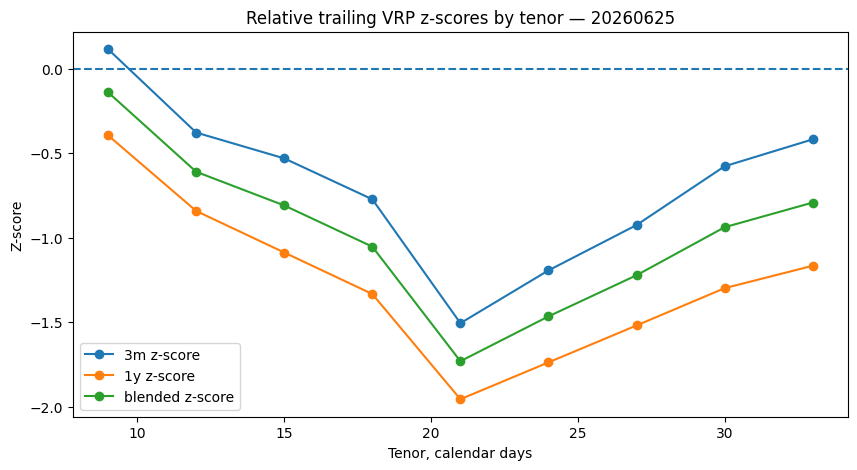

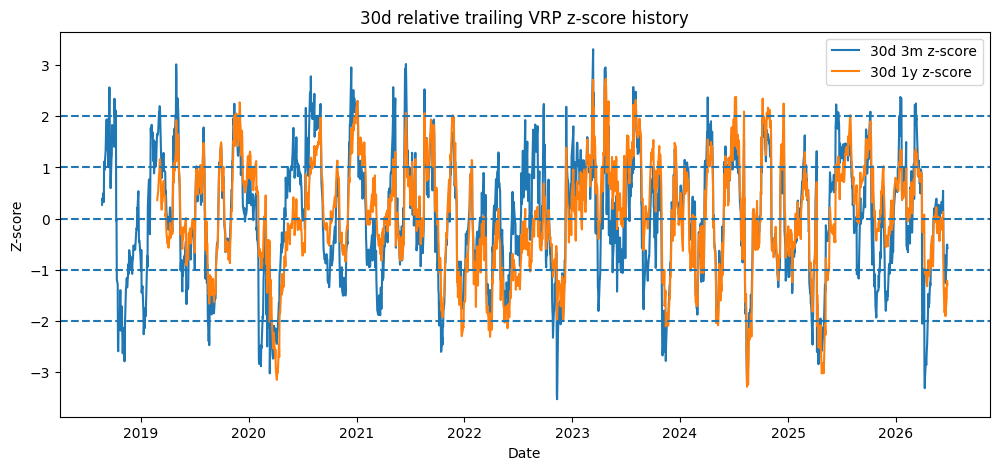

In [15]:
# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    latest_snapshot_df["target_days"],
    latest_snapshot_df["vrp_log_ratio_3m_z"],
    marker="o",
    label="3m z-score",
)
plt.plot(
    latest_snapshot_df["target_days"],
    latest_snapshot_df["vrp_log_ratio_1y_z"],
    marker="o",
    label="1y z-score",
)
plt.plot(
    latest_snapshot_df["target_days"],
    latest_snapshot_df["vrp_log_ratio_blended_z"],
    marker="o",
    label="blended z-score",
)
plt.axhline(0, linestyle="--")
plt.title(f"Relative trailing VRP z-scores by tenor — {latest_trade_date}")
plt.xlabel("Tenor, calendar days")
plt.ylabel("Z-score")
plt.legend()
plt.show()

plot_30d_df = zscore_df[zscore_df["target_days"] == 30].copy()
plot_30d_df["date"] = pd.to_datetime(plot_30d_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(plot_30d_df["date"], plot_30d_df["vrp_log_ratio_3m_z"], label="30d 3m z-score")
plt.plot(plot_30d_df["date"], plot_30d_df["vrp_log_ratio_1y_z"], label="30d 1y z-score")
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("30d relative trailing VRP z-score history")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.show()


## 8. Save outputs


In [16]:
# ============================================================
# Save outputs
# ============================================================

zscore_df.to_csv(ZSCORE_PANEL_CSV, index=False)
zscore_df.to_parquet(ZSCORE_PANEL_PARQUET, index=False)

richest_by_date_df.to_csv(RICHEST_BY_DATE_CSV, index=False)
richest_by_date_df.to_parquet(RICHEST_BY_DATE_PARQUET, index=False)

preferred_tenor_df.to_csv(PREFERRED_TENOR_CSV, index=False)
preferred_tenor_df.to_parquet(PREFERRED_TENOR_PARQUET, index=False)

latest_snapshot_df.to_csv(LATEST_SNAPSHOT_CSV, index=False)
tenor_frequency_df.to_csv(TENOR_FREQUENCY_CSV, index=False)
endpoint_middle_summary.to_csv(ENDPOINT_MIDDLE_SUMMARY_CSV, index=False)
winner_comparison_df.to_csv(WINNER_COMPARISON_CSV, index=False)
threshold_sensitivity_df.to_csv(THRESHOLD_SENSITIVITY_CSV, index=False)
interior_richest_by_date_df.to_csv(INTERIOR_RICHEST_CSV, index=False)

print("Saved z-score CSV:", ZSCORE_PANEL_CSV)
print("Saved z-score parquet:", ZSCORE_PANEL_PARQUET)

print("Saved richest-tenor CSV:", RICHEST_BY_DATE_CSV)
print("Saved richest-tenor parquet:", RICHEST_BY_DATE_PARQUET)

print("Saved preferred tenor CSV:", PREFERRED_TENOR_CSV)
print("Saved preferred tenor parquet:", PREFERRED_TENOR_PARQUET)

print("Saved latest snapshot audit:", LATEST_SNAPSHOT_CSV)
print("Saved tenor frequency audit:", TENOR_FREQUENCY_CSV)
print("Saved endpoint/middle audit:", ENDPOINT_MIDDLE_SUMMARY_CSV)
print("Saved winner comparison audit:", WINNER_COMPARISON_CSV)
print("Saved threshold sensitivity audit:", THRESHOLD_SENSITIVITY_CSV)
print("Saved interior richest audit:", INTERIOR_RICHEST_CSV)

print("\nRows in z-score panel:", len(zscore_df))
print("Dates in richest-tenor summary:", len(richest_by_date_df))
print("Dates in preferred-tenor summary:", len(preferred_tenor_df))


Saved z-score CSV: C:\Users\patri\vrp_project\data\processed\vrp_zscore_panel_v0_1.csv
Saved z-score parquet: C:\Users\patri\vrp_project\data\processed\vrp_zscore_panel_v0_1.parquet
Saved richest-tenor CSV: C:\Users\patri\vrp_project\data\processed\richest_vrp_tenor_by_date_v0_1.csv
Saved richest-tenor parquet: C:\Users\patri\vrp_project\data\processed\richest_vrp_tenor_by_date_v0_1.parquet
Saved preferred tenor CSV: C:\Users\patri\vrp_project\data\processed\preferred_vrp_tenor_by_date_v0_1.csv
Saved preferred tenor parquet: C:\Users\patri\vrp_project\data\processed\preferred_vrp_tenor_by_date_v0_1.parquet
Saved latest snapshot audit: C:\Users\patri\vrp_project\data\audit\latest_vrp_zscore_snapshot_v0_1.csv
Saved tenor frequency audit: C:\Users\patri\vrp_project\data\audit\richest_tenor_frequency_v0_1.csv
Saved endpoint/middle audit: C:\Users\patri\vrp_project\data\audit\endpoint_middle_selection_summary_v0_1.csv
Saved winner comparison audit: C:\Users\patri\vrp_project\data\audit\endp